# Calculation of coherent elastic neutrino-electron scattering E$\nu$ES

In this notebook we outline how to generate E$\nu$ES rate. First we show how to do it for the SM and then for non-zero NSI parameters. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe, binding_ar    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared

Setting up the target of the DD experiment:

In [3]:
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 
Ar_nucleus = Nucleus(18, 40, mass=39.96238312 * config.u) # only do one isotope for this example 

## SM E$\nu$ES scattering rate 

 We generate an instance of the SM (in terms of zero NSI) and compute and plot the theoretical (i.e. without including any experimental effects) E$\nu$ES rate in Xe.

In [4]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

SM_eta = 0
SM_phi = 0

sm_model = GeneralNSI(SM_matrix, SM_eta, SM_phi)

Update the nucleus object with the NSI model, i.e. the SM in this case.

In [5]:
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

Ar_electron = Electron(Ar_nucleus, binding_ar) 
Ar_electron.update_model(sm_model)
Ar_electron.prepare_density()

In [6]:
E_Rs = np.logspace(-3, 2, 1000) / 1e6  # Recoil Energy in GeV

In [7]:
sm_spec_xe = Xe_electron.spectrum(E_Rs) 
sm_spec_ar = Ar_electron.spectrum(E_Rs) 

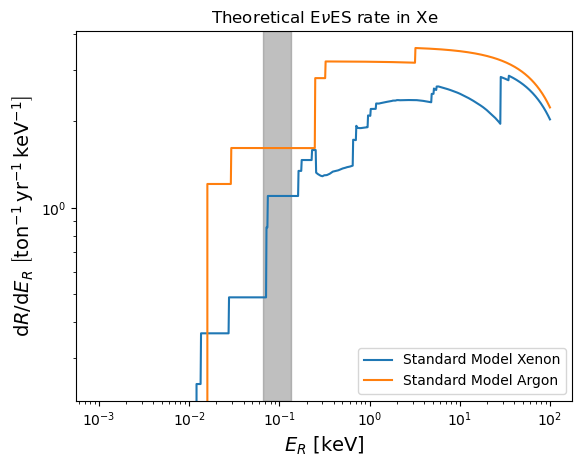

In [25]:
plt.loglog(E_Rs*1e6, abs(sm_spec_xe), label="Standard Model Xenon")
plt.loglog(E_Rs*1e6, abs(sm_spec_ar), label="Standard Model Argon")


plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)


plt.axvspan(66e-3, 133e-3, color='gray', alpha=0.5, label='PDX energy range')
#plt.xlim(xmin=1e-1, xmax=1e2)
#plt.ylim(ymax=5e0, ymin=5e-1)

In [26]:
E_Rs_PDx = np.geomspace(66e-3, 133e-3, 100) / 1e6  # Recoil Energy in GeV

In [27]:
sm_spec_xePDx = Xe_electron.spectrum(E_Rs_PDx) 


In [30]:
np.trapz(sm_spec_xePDx, x=E_Rs_PDx) * 1.04 # Integrate the spectrum to get the total rate

(7.24172848461517e-08+0j)

In [32]:
np.trapz(sm_spec_xe, x=E_Rs) * 1.04 # Integrate the spectrum to get the total rate

(0.00025205245581806375+0j)

In [29]:
sm_spec_xePDx

array([0.48793212+0.j, 0.48793131+0.j, 0.48793049+0.j, 0.48792967+0.j,
       0.48792884+0.j, 0.487928  +0.j, 0.48792716+0.j, 0.48792632+0.j,
       0.48792546+0.j, 0.4879246 +0.j, 0.48792374+0.j, 0.48792286+0.j,
       0.85386347+0.j, 0.85386193+0.j, 0.85386037+0.j, 0.8538588 +0.j,
       1.09781642+0.j, 1.09781438+0.j, 1.09781232+0.j, 1.09781024+0.j,
       1.09780815+0.j, 1.09780604+0.j, 1.09780392+0.j, 1.09780179+0.j,
       1.09779964+0.j, 1.09779747+0.j, 1.09779529+0.j, 1.09779309+0.j,
       1.09779088+0.j, 1.09778866+0.j, 1.09778641+0.j, 1.09778415+0.j,
       1.09778188+0.j, 1.09777959+0.j, 1.09777728+0.j, 1.09777496+0.j,
       1.09777262+0.j, 1.09777026+0.j, 1.09776789+0.j, 1.0977655 +0.j,
       1.09776309+0.j, 1.09776067+0.j, 1.09775823+0.j, 1.09775577+0.j,
       1.09775329+0.j, 1.09775079+0.j, 1.09774828+0.j, 1.09774575+0.j,
       1.0977432 +0.j, 1.09774063+0.j, 1.09773805+0.j, 1.09773545+0.j,
       1.09773282+0.j, 1.09773019+0.j, 1.09772753+0.j, 1.09772485+0.j,
      

## NSI E$\nu$ES scattering rate 

Now do the same for a non-zero NSI $\varepsilon_{e\mu}=0.1$ coupling with electrons ($\varphi=-\pi/2$).

In [9]:
NSI_matrix = np.array([[0.0, 0.1, 0.0],
                       [0.1, 0.0, 0.0],
                       [0.0, 0.0, 0.0]])

NSI_eta = 0.0
NSI_phi = -np.pi/2

NSI_model = GeneralNSI(NSI_matrix, NSI_eta, NSI_phi)

Update the nucleus object with the new NSI model and compute the new spectrum.

In [10]:
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling)
Xe_electron.update_model(NSI_model)
Xe_electron.prepare_density()

In [11]:
NSI_spec = Xe_electron.spectrum(E_Rs)

Plotting the SM and NSI spectra.

(0.5, 5.0)

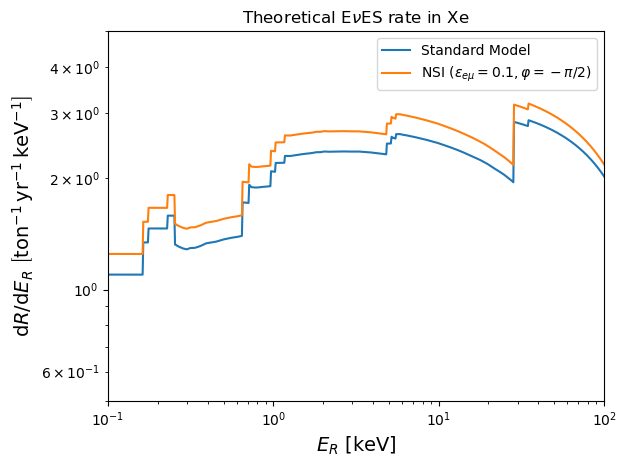

In [12]:
plt.loglog(E_Rs*1e6, abs(sm_spec), label="Standard Model")
plt.loglog(E_Rs*1e6, abs(NSI_spec), label=r"NSI ($\varepsilon_{e\mu}=0.1, \varphi=-\pi/2$)")

plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)

plt.xlim(xmin=1e-1, xmax=1e2)
plt.ylim(ymax=5e0, ymin=5e-1)